<a href="https://colab.research.google.com/github/Laot-203/Ast-332/blob/main/Semana2/Semana02_EDA_Titanic_actividad_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos.
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas.
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [54]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**
En total hay 3 variables numéricas; la edad, "Age". La clase, "Pclass" y el genero "Sex". Mientras que se encuentran 5 clases categóricas; la supervivencia, "Survived". El numero de hermanos o cónyuges, "SibSp". El numero de padres o hijos, "Parch". La cabina, "Cabin" y la zona de embarque "Embarked".


# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


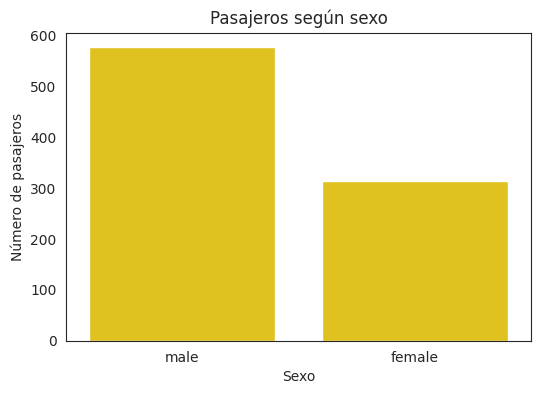

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


<function matplotlib.pyplot.show(close=None, block=None)>

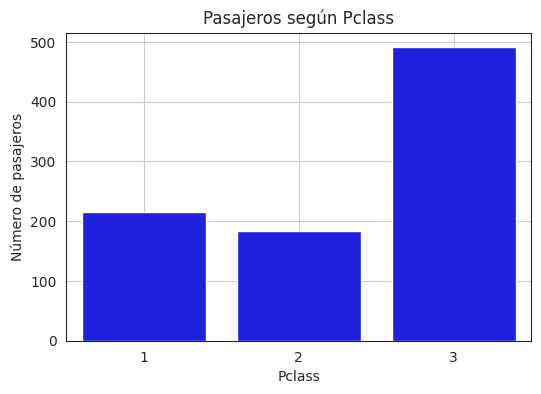

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(data=titanic, x='Pclass', color='blue')

plt.xlabel('Pclass')
plt.ylabel('Número de pasajeros')
plt.title('Pasajeros según Pclass')

plt.grid(True)
plt.show
#Por el gréfico mostrado, se puede apreciar que la tercera clase era la más abundante.
#Ni siquiera juntando las 2 primeras clases se alcanza la cantidad de personas que hay en la 3ra clase.

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


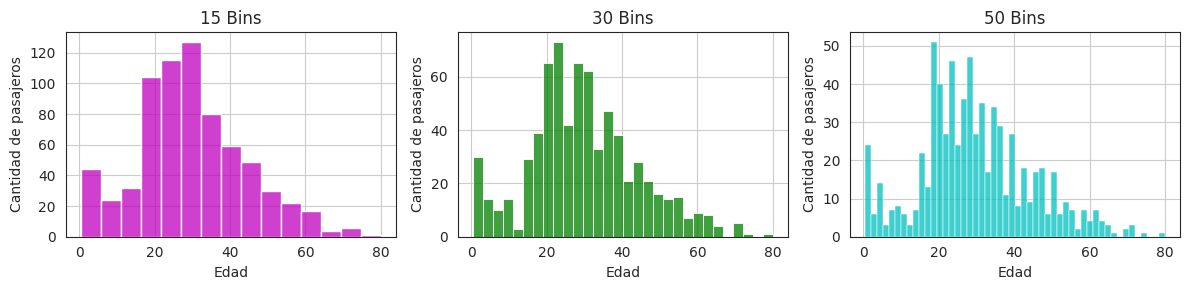

In [57]:
plt.figure(figsize=(12,3))

plt.subplot(1, 3, 1)
sns.histplot(data=titanic, x='Age', bins=15, color='m')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('15 Bins')
plt.grid(True)

plt.subplot(1, 3, 2)
sns.histplot(data=titanic, x='Age', bins=30, color='g')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('30 Bins')
plt.grid(True)

plt.subplot(1, 3, 3)
sns.histplot(data=titanic, x='Age', bins=50, color='c')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('50 Bins')
plt.grid(True)

plt.tight_layout()
plt.show()

#La edad más común es de 30 años.
#Llega a parecer una campana de Gauss,pero con un mayor indice en los 0 años.
#Si, la cantidad de Bins nos da más claridad de las edades y su distribución.

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


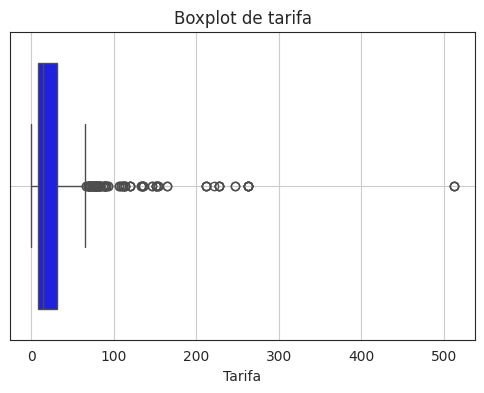

In [58]:
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x='Fare', color='b')

plt.xlabel('Tarifa')
plt.title('Boxplot de tarifa')

plt.grid(True)
plt.show()

#La distribución muestra bastante tendencia con varios saltos de la norma.
#Si, existe una tarifa en particular que es extremadamente cara.
#Puede ser por una sobreventa, o un boleto de clase única.

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [59]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


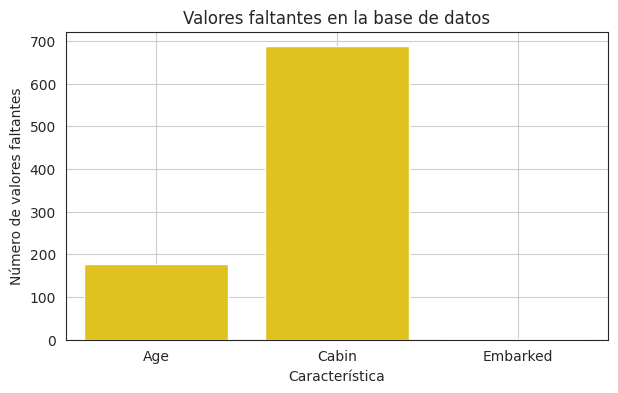

In [60]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.grid(True)
plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


In [61]:
media = titanic['Age'].mean()
mediana = titanic['Age'].median()

print(f'Media: {media:.2f}')
print(f'Mediana: {mediana:.2f}')

#Si, llegan a se similares y en base al gráfico de la parte 1, es una buena
#edad típica para representar la tripulación.

Media: 29.70
Mediana: 28.00


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media? r: No, debido a que eso le daría más peso a ese valor.
- Qué problema podría producir esa decisión en la distribución de edades? r: Al generar más peso a ese dato desregula el peso del resto de edades.
- Qué otra estrategia consideraría? r: generar edades aleatorias e introducirlas o mantenerlo así, sin valores, para generar un margen de error.


**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos? r: No, por lo mismo de antes que desregulariza los datos que si existe.
- Eliminaría la característica? r: Podría ser, dependiendo si es que los datos faltantes superan la media, si genera eso, los datos tendrán mucho margen de error.
- Podría el hecho de conocer o no la cabina contener información por sí mismo? r: Si, porque nos dice en qué lugar podría haber estado posicionado durante el accidente.

No hay una única respuesta correcta: justifique su decisión.


**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso? r: Darle datos aleatorios.
- Por qué el tratamiento puede ser distinto al de `Cabin`? r: Porque el peso de que tiene esto en los datos, es muchisimo menor en comparación.


# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


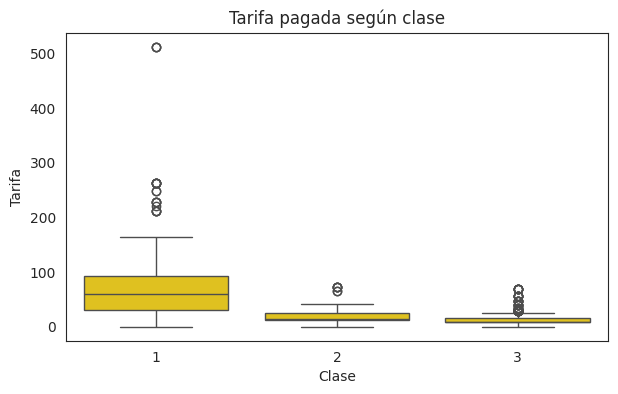

In [62]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase? r: Si, se aprecia que la cantidad de dinero gastado es mayor según cada clase.
- Hay dispersión dentro de cada clase? r: Si se aprecia excepciones entre cada clase se pudo habar pagado más de la norma.
- Existen valores extremos? r: Si, se aprecia destacadamente en la clase 1 con 1 dato en preciso, mientras que el resto llegan a tener un par que si se consideran excepciones.
- Diría que `Fare` y `Pclass` contienen exactamente la misma información? r: No diría que exactamente la misma, pero si son correlacionadas, debido a que una nos muestra el poder adquisitivo "Fare", mientras que el otro nos muestra el el estratus social "Pclass". Ambos a grandes rasgos.


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


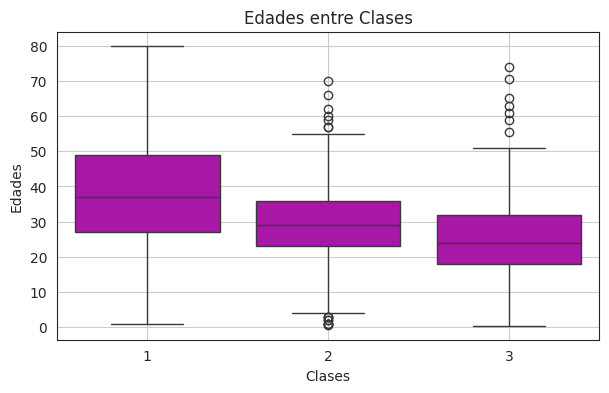

In [63]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x='Pclass', y='Age', color='m')

plt.xlabel('Clases')
plt.ylabel('Edades')
plt.title('Edades entre Clases')

plt.grid(True)
plt.show()

#Si, los margenes de error son menores y hay claramente más tendencias claras
#en cada clase, apreciando las medianas de cada clase; clase 1 cercana a los
#40 años, la mediana de la clase 2 en los 30 años y la clase 3 en los 25 años.

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [64]:
# Complete el código

titanic["Familia"] = titanic['SibSp'] + titanic['Parch'] + 1
print(titanic['Familia'].head())

#Con la ayuda del encabezado, se suman los 2 datos más la propia persona (1).


0    2
1    2
2    1
3    2
4    1
Name: Familia, dtype: int64


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


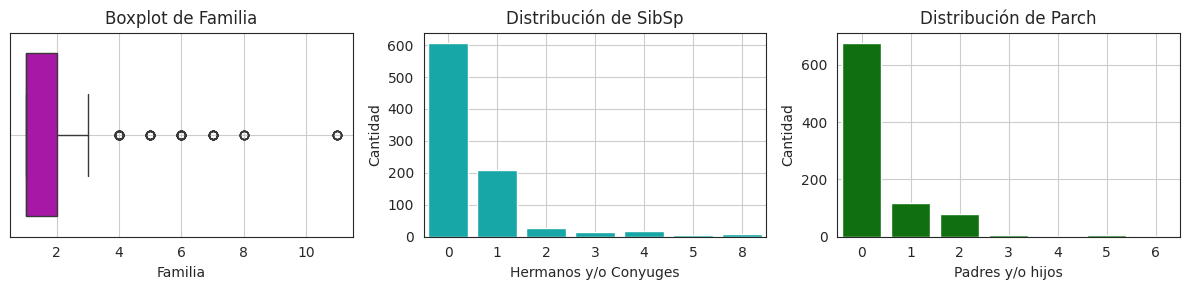

In [65]:
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
sns.boxplot(data=titanic, x='Familia', color='m')
plt.xlabel('Familia')
plt.title('Boxplot de Familia')
plt.grid(True)

plt.subplot(1,3,2)
sns.countplot(data=titanic, x='SibSp', color='c')
plt.xlabel('Hermanos y/o Conyuges')
plt.ylabel('Cantidad')
plt.title('Distribución de SibSp')
plt.grid(True)

plt.subplot(1,3,3)
sns.countplot(data=titanic, x='Parch', color='green')
plt.xlabel('Padres y/o hijos')
plt.ylabel('Cantidad')
plt.title('Distribución de Parch')
plt.grid(True)

plt.tight_layout()
plt.show()

#La mayoria de las personas viajaban solas o con 1 solo acompañante
#Si los hay, se nota en el Boxplot que hay excepciones de más de 6 integrantes.
#No, porque si se miran por separado se llega a la misma conclusión de antes.

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


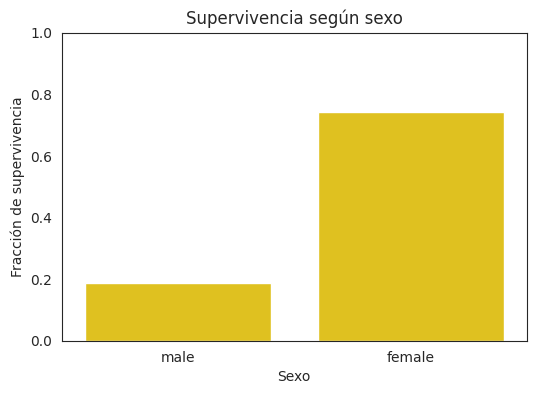

In [66]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres? r: No, la tasa de supervivencia de mujeres fue más del doble que la de hombres.
- Podemos concluir a partir de este gráfico por qué existe la diferencia? r: No se puede concluir exactamente, pero se puede suponer que se priorizó salvar a las mujeres.


### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


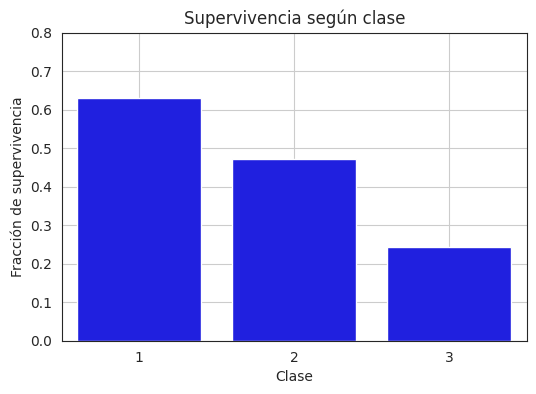

In [67]:
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x='Pclass', y='Survived', errorbar=None, color='b')

plt.xlabel('Clase')
plt.ylabel('Fracción de supervivencia')
plt.title('Supervivencia según clase')
plt.ylim(0,0.8)

plt.grid(True)
plt.show()

#Si, la clase 1 sobrevivió casi 3 veces más que la clase 1.
#Si, la tendencia es que: entre mayor fuera la clase, más alta es
#la supervivencia.

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


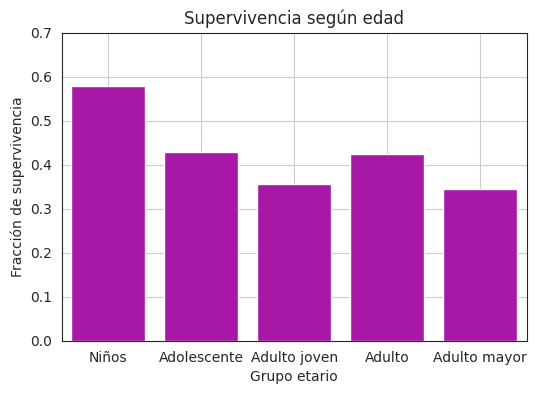

In [68]:
#Lo intententé varias veces con distinto tamaño, los separaré en rangos etarios.
#Rangos: [0-12], [12-18], [18,30], [30-50], [50-80].
plt.figure(figsize=(6,4))

bins = [0, 12, 18, 30, 50, 80]
labels = ['Niños', 'Adolescente', 'Adulto joven', 'Adulto', 'Adulto mayor']
titanic['GrupoEdad'] = pd.cut(titanic['Age'], bins=bins, labels=labels)

sns.barplot(data=titanic, x='GrupoEdad', y='Survived', errorbar=None, color='m')

plt.xlabel('Grupo etario')
plt.ylabel('Fracción de supervivencia')
plt.title('Supervivencia según edad')
plt.ylim(0,0.7)

plt.grid(True)
plt.show()

#Si, el grupo que más sobrevivió fueron los niños.
#Si, el grupo de adulto joven sobrevivió menos que los adolescentes y
#los adultos.

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


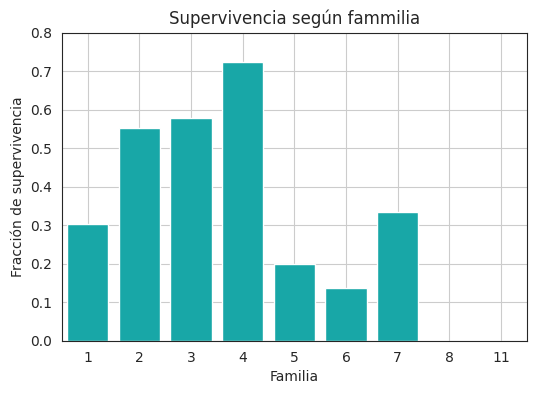

In [69]:
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x='Familia', y='Survived', errorbar=None, color='c')

plt.xlabel('Familia')
plt.ylabel('Fracción de supervivencia')
plt.title('Supervivencia según fammilia')
plt.ylim(0,0.8)

plt.grid(True)
plt.show()

#Viajar solo no es favorable, viajar con al menos 1 persona más aumenta la tasa
#de supervivencia a casi el doble.
#Los grupos familiares grandes tienden a no sobrevivir, no así los grupos
#de 7 personas. Por lo que se puede inferir que un vote contiene 8 asientos, 7
#para el grupo familiar y 1 para el rescatista.

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


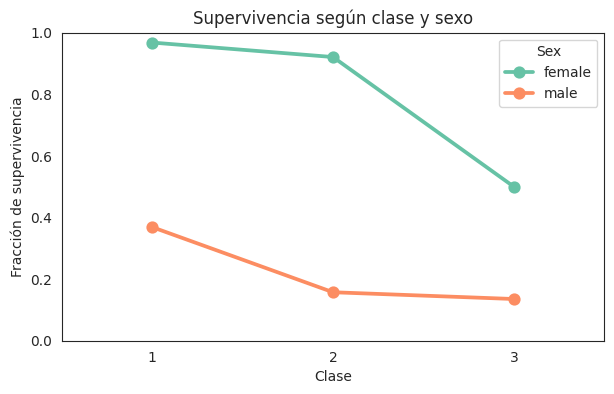

In [70]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres? r: la relación es distinta entre sexos y clase, el cambio de pendiente se genera en distintos parámetros en cada uno.
- Qué información se perdía cuando mirábamos solamente `Pclass`? r: Se perdía el sexo de la persona según su clase.
- Qué información se perdía cuando mirábamos solamente `Sex`? r: Se perdía la sercanía a la superficie del barco.
- Hay algún grupo particularmente favorecido o desfavorecido? r: Si, la pendiente entre cada cambio de clase es distinta según el sexo, la pendiente de las mujeres es más empinada que la de los hombres, por ende entre menor clase menor la tasa de supervivencia femenina.



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [71]:
# Complete el código
#Como está la libreria numpy, se utilizará esta

titanic["Persona"] = np.select(
    [titanic['Age'] < 16, titanic['Sex'] == 'female'],
    ['niño/a', 'mujer'],
    default = 'hombre'
)

# Revise el resultado
titanic["Persona"].value_counts()


,count
Persona,
hombre,537
mujer,271
niño/a,83


**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


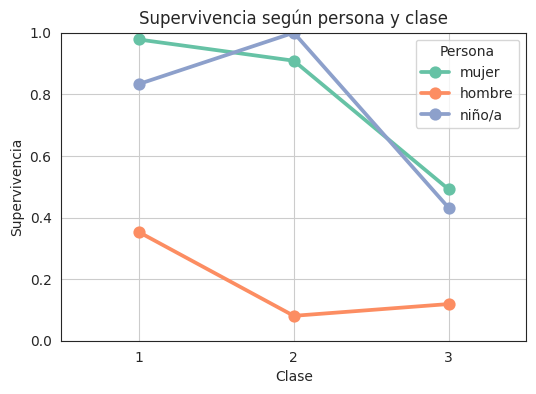

In [72]:
plt.figure(figsize = (6,4))
sns.pointplot(data = titanic,
              x = 'Pclass',
              y = 'Survived',
              hue = 'Persona',
              palette = 'Set2',
              errorbar = None)

plt.xlabel('Clase')
plt.ylabel('Supervivencia')
plt.title('Supervivencia según persona y clase')
plt.ylim(0,1)

plt.grid(True)
plt.show()

#No, los niños presentan un crecimiento en el cambio de clase de 1 a 2
#y el cabio es más brusco en el cambio de clase 2 a 3.
#Si, la clase sigue demostrando una clara dependencia de supervivencia,
#sobretodo en las clases 1 y 2.
#La combinación que parece con mayor supervivencia, son la de las
#mujeres con los niños.

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


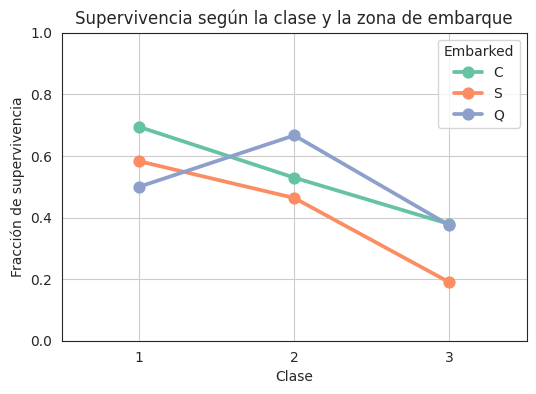

In [74]:
#Utilizaré la opción 3; puerto de embarque + clase + supervivencia

# Pregunta: ¿El puerto de embarque nos dirá alguna tendencia de la clase y
#su supervivencia?

# Código:
plt.figure(figsize=(6,4))
sns.pointplot(data = titanic,
              x = 'Pclass',
              y = 'Survived',
              hue = 'Embarked',
              palette = 'Set2',
              errorbar = None)

plt.xlabel('Clase')
plt.ylabel('Fracción de supervivencia')
plt.title('Supervivencia según la clase y la zona de embarque')
plt.ylim(0,1)

plt.grid(True)
plt.show()

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.

r: Se puede representar a las personas que se subieron al titanic: desde familias pequeñas hasta familias numerosas, con solo adultos y hasta con niños de todas las edades (adolescentes, adultos jovenes, etc) de diversos niveles adquisitivos. Y también se puede apreciar personas solas, hombres y mujeres en distintos estratos, con una mayor concentración de mujeres en clases altas.

### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.

r: Se contempla y evidencia que entre más joven y siendo mujer, más probabilidades de sobrevivir se tiene. Mientras que si se viaja solo es más probable que se sobreviva a viajar en una familia masiva, lo mejor era que se viajara con 1 o 2 personas más. Además que se observa como entre mayor la clase, mayor la posibilidad de sobrevivir.

### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.

r: Un análisis que cambió, fue el de niños/as con mujeres y hombres, podemos observar que este, añadiendo las clases nos entregó información al contrario de lo previsto con otros gráficos.

### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.

r: Si, la clase con la cantidad de supervivencia nos dice que entre mayor la clase es, mayor es la cantidad de sobrevivir

### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.

r: El resultado que más me imprecionó fue el precio por clase, en donde se aprecia un punto, extremadamente alto en la clase 1. Por ende como hipotesis pienso que fue en una subasta por la habitación más lujosa existente.

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.

### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*

r: El pasajeto típico que sobrevivió fue una niña con menos de 12 años, embarcandose en "Q", con su familia de 4 integrantes, en segunda clase.